<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/17_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS**

##**Objective:**
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.


**Data Preparation**

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("exchange_rate.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7588, 1)

First 5 Rows:
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Data Types:
Ex_rate    float64
dtype: object

Missing Values:
Ex_rate    0
dtype: int64


**Time Series Exploration**

Summary Statistics:
count    7588.000000
mean        0.776974
std         0.136620
min         0.483297
25%         0.701422
50%         0.761377
75%         0.873477
max         1.102536
Name: Ex_rate, dtype: float64

Duplicate Dates: 0

Missing Values: 0


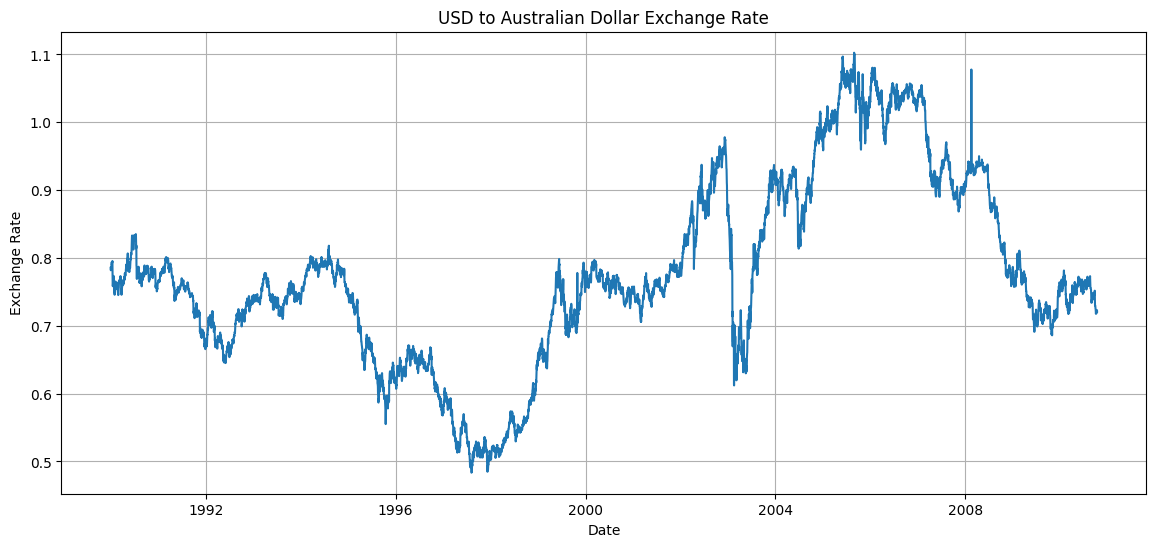

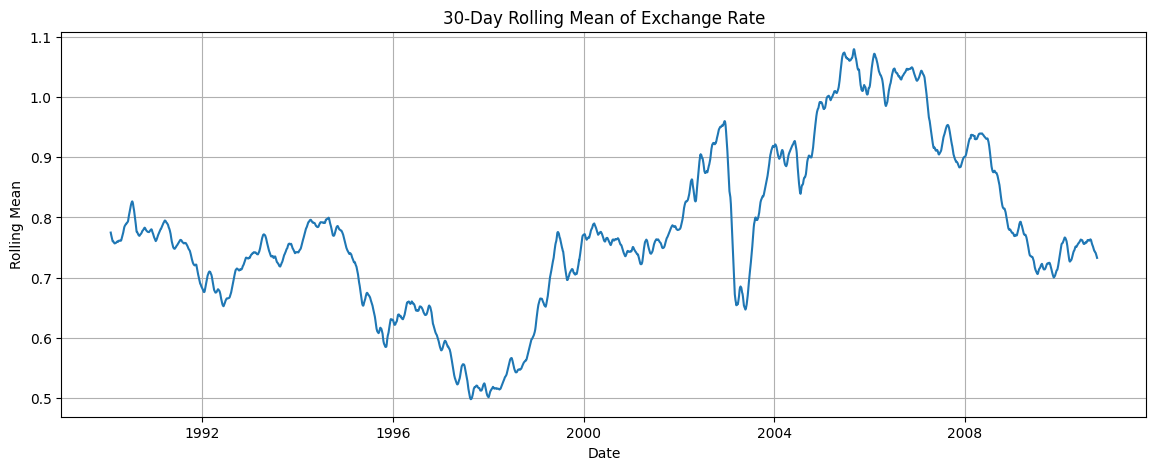

In [ ]:

print("Summary Statistics:")
print(df["Ex_rate"].describe())

print("\nDuplicate Dates:", df.index.duplicated().sum())

print("\nMissing Values:", df["Ex_rate"].isnull().sum())

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Ex_rate"])
plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["Ex_rate"].rolling(30).mean())
plt.title("30-Day Rolling Mean of Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Rolling Mean")
plt.grid()
plt.show()

**Data Preprocessing**

In [ ]:

series = df["Ex_rate"].copy()

series = series.replace([np.inf, -np.inf], np.nan)
series = series.interpolate(method="time")
series = series.ffill().bfill()

print("Missing Values After Handling:", series.isnull().sum())
print("Infinite Values After Handling:", np.isinf(series).sum())

Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((series < lower_bound) | (series > upper_bound)).sum()

print("Potential Outliers:", outliers)
print("Outliers are retained because extreme exchange-rate movements can represent genuine market behavior.")

Missing Values After Handling: 0
Infinite Values After Handling: 0
Potential Outliers: 0
Outliers are retained because extreme exchange-rate movements can represent genuine market behavior.


**Stationarity and Differencing**

In [ ]:

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] > 0.05:
    stationary_series = series.diff().dropna()
    d = 1
    print("Series is treated as non-stationary. First differencing is applied.")
else:
    stationary_series = series
    d = 0
    print("Series is stationary. No differencing is required.")

print("Selected d:", d)

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Series is treated as non-stationary. First differencing is applied.
Selected d: 1


**ACF and PACF Analysis**

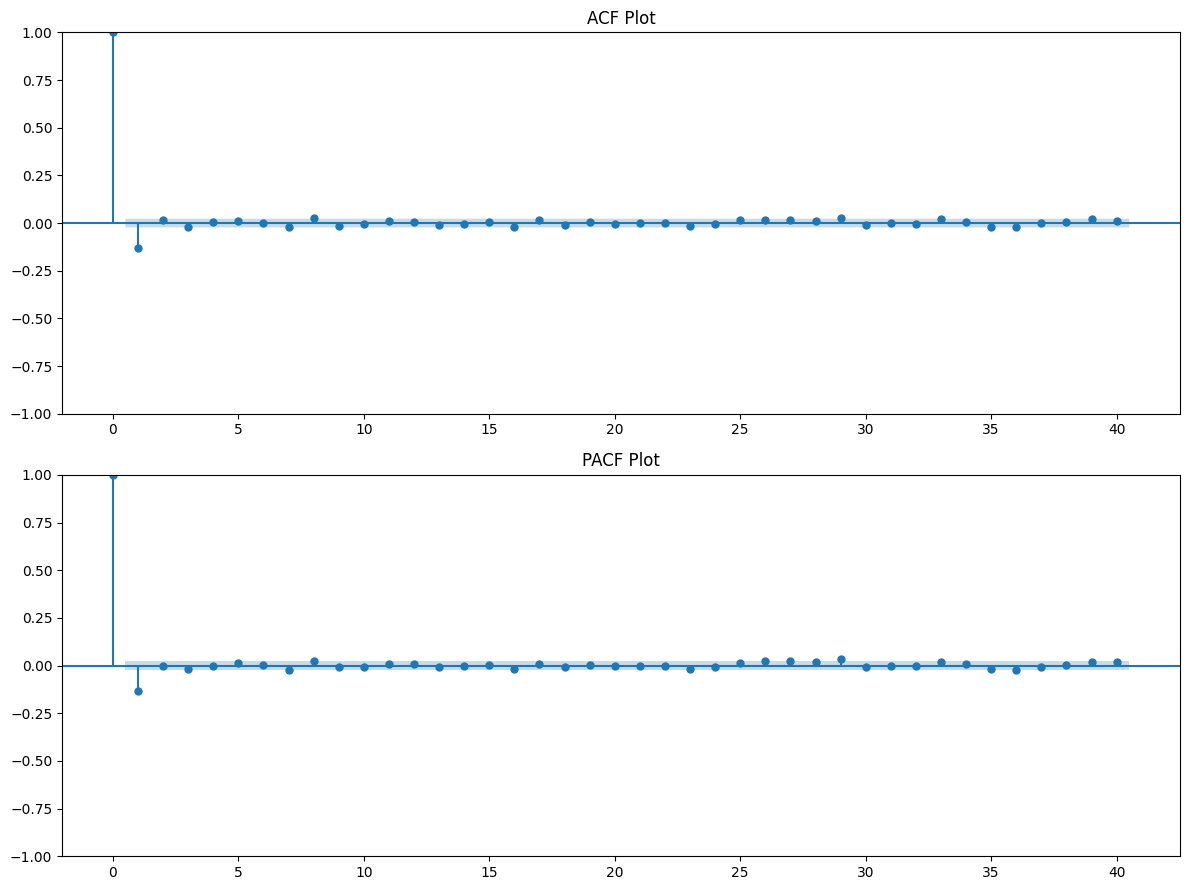

In [ ]:

lags = min(40, len(stationary_series) // 2 - 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

plot_acf(stationary_series, lags=lags, ax=axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(stationary_series, lags=lags, ax=axes[1], method="ywm")
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

**ARIMA Parameter Selection**

In [ ]:

p_values = range(0, 3)
q_values = range(0, 3)

arima_results = []

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(series, order=(p, d, q))
            fitted = model.fit()

            arima_results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fitted.aic
            })
        except:
            pass

arima_results = pd.DataFrame(arima_results)
arima_results = arima_results.sort_values("AIC")

print(arima_results)

best_p = int(arima_results.iloc[0]["p"])
best_q = int(arima_results.iloc[0]["q"])

print("\nSelected ARIMA Order:", (best_p, d, best_q))

   p  d  q           AIC
3  1  1  0 -56104.318870
1  0  1  1 -56102.753412
4  1  1  1 -56102.321674
6  2  1  0 -56102.321009
2  0  1  2 -56101.864245
5  1  1  2 -56101.590992
7  2  1  1 -56100.314755
8  2  1  2 -56100.135331
0  0  1  0 -55974.195367

Selected ARIMA Order: (1, 1, 0)


**Train Test Split**

In [ ]:

test_size = int(len(series) * 0.20)

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Training Observations:", len(train))
print("Testing Observations:", len(test))
print("Training Period:", train.index.min(), "to", train.index.max())
print("Testing Period:", test.index.min(), "to", test.index.max())

Training Observations: 6071
Testing Observations: 1517
Training Period: 1990-01-01 00:00:00 to 2006-08-15 00:00:00
Testing Period: 2006-08-16 00:00:00 to 2010-10-10 00:00:00


**ARIMA Model**

In [ ]:

arima_model = ARIMA(
    train,
    order=(best_p, d, best_q)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6071
Model:                 ARIMA(1, 1, 0)   Log Likelihood               22719.172
Date:                Mon, 05 Oct 2026   AIC                         -45434.343
Time:                        05:47:30   BIC                         -45420.921
Sample:                    01-01-1990   HQIC                        -45429.685
                         - 08-15-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0597      0.005    -11.762      0.000      -0.070      -0.050
sigma2      3.285e-05   1.85e-07    177.983      0.000    3.25e-05    3.32e-05
Ljung-Box (L1) (Q):                   0.01   Jarque-

**Exponential Smoothing Model**

In [ ]:

es_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

es_fit = es_model.fit(optimized=True)

es_forecast = es_fit.forecast(steps=len(test))
es_forecast.index = test.index

print(es_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6071
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62666.892
Trend:                         Additive   BIC                         -62640.047
Seasonal:                          None   AICC                        -62666.878
Seasonal Periods:                  None   Date:                 Mon, 05 Oct 2026
Box-Cox:                          False   Time:                         05:47:31
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428906                alpha                 True
smoothing_trend             0.0000

**Forecast Visualization**

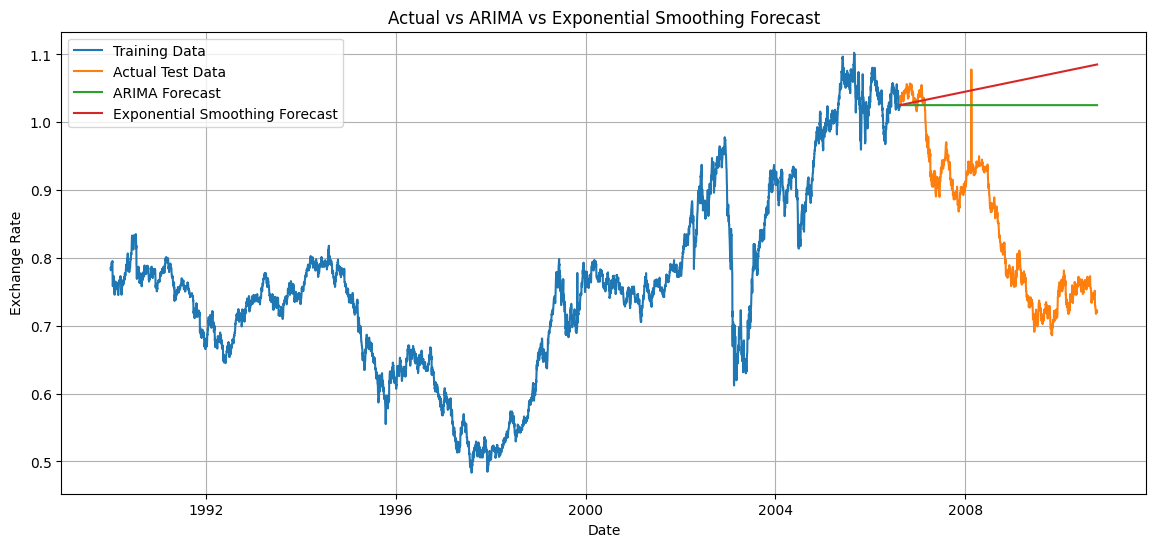

In [ ]:

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.plot(test.index, es_forecast, label="Exponential Smoothing Forecast")

plt.title("Actual vs ARIMA vs Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid()
plt.show()

**Forecast Evaluation**

In [ ]:

def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    non_zero_actual = actual.replace(0, np.nan)
    mape = np.mean(
        np.abs((actual - predicted) / non_zero_actual)
    ) * 100
    return mae, rmse, mape

arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test, arima_forecast
)

es_mae, es_rmse, es_mape = calculate_metrics(
    test, es_forecast
)

results = pd.DataFrame({
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [arima_mae, es_mae],
    "RMSE": [arima_rmse, es_rmse],
    "MAPE (%)": [arima_mape, es_mape]
})

print(results)

                   Model       MAE      RMSE   MAPE (%)
0                  ARIMA  0.179047  0.206868  22.968096
1  Exponential Smoothing  0.208249  0.240837  26.717611


**ARIMA Residual Diagnostics**

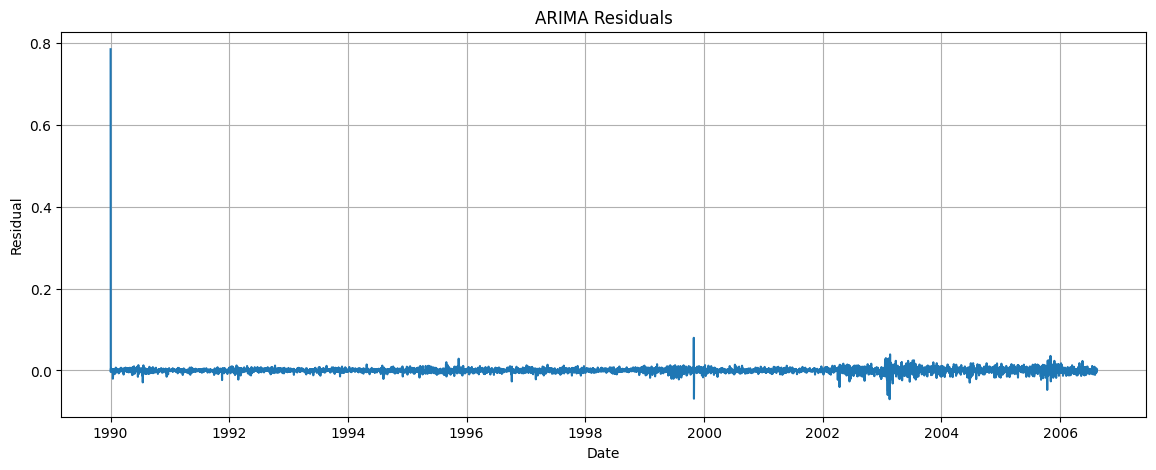

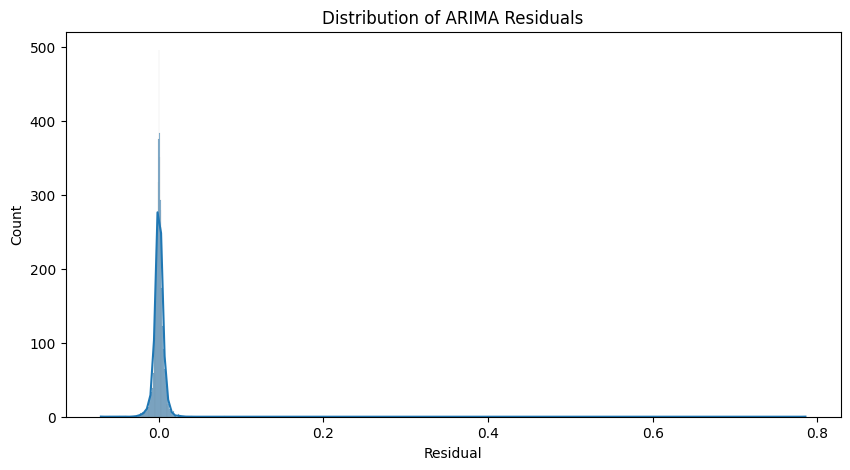

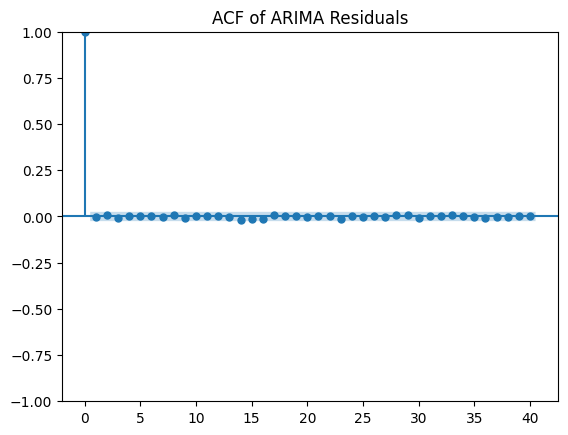

Ljung-Box Test:
     lb_stat  lb_pvalue
10  2.492603   0.990983
20  6.854912   0.997134


In [ ]:

residuals = arima_fit.resid

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.show()

plot_acf(residuals.dropna(), lags=40)
plt.title("ACF of ARIMA Residuals")
plt.show()

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)

print("Ljung-Box Test:")
print(ljung_box)

**Model Comparison**

In [ ]:

best_model = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

print("Model Comparison:")
print(results)

print("\nBest Model Based on RMSE:", best_model)

print("\nLower MAE indicates smaller average forecasting errors.")
print("Lower RMSE indicates fewer large forecasting errors.")
print("Lower MAPE indicates lower percentage forecasting error.")

Model Comparison:
                   Model       MAE      RMSE   MAPE (%)
0                  ARIMA  0.179047  0.206868  22.968096
1  Exponential Smoothing  0.208249  0.240837  26.717611

Best Model Based on RMSE: ARIMA

Lower MAE indicates smaller average forecasting errors.
Lower RMSE indicates fewer large forecasting errors.
Lower MAPE indicates lower percentage forecasting error.


##**ARIMA vs Exponential Smoothing**
**ARIMA** models the relationship between current and previous observations and can handle autocorrelation and differencing in time-series data. ACF and PACF plots are useful for selecting initial ARIMA parameters.

**Exponential Smoothing** gives greater importance to recent observations and is useful for forecasting series with level and trend components.

ARIMA can be more flexible for series with autocorrelation, while Exponential Smoothing can provide a simpler approach for level and trend forecasting.

The final model should be selected using the actual **MAE**, **RMSE**, and **MAPE** results obtained from the test data.

##**Conclusion**
* The forecasting performance of ARIMA and Exponential Smoothing is compared using MAE, RMSE, and MAPE. The model with lower forecasting errors provides better performance for this dataset.

* The final selection should consider both the error metrics and residual diagnostics. A good forecasting model should produce accurate forecasts while leaving residuals without significant remaining patterns.

* This assignment demonstrates how historical exchange-rate data can be used to build and evaluate time-series forecasting models.